# 07_Sampling

### What is Sampling?

Sampling is the process of selecting a subset (sample) of individuals or observations from a larger population, in order to estimate characteristics of the whole population without examining every member.


## 01. Random Sampling (Simple Random Sampling)

**Definition**: Simple Random Sampling is a method where every member of the population has an equal and independent chance of being selected into the sample. Selection is done purely by chance, with no bias in who is picked.

**Formula**: 
Probability of selecting any individual = 1/N, where N = population size.
For sampling without replacement: P(selecting a specific sample of size n) = 1 / C(N, n)

**Where it is used**: Used when the population is homogeneous (similar characteristics) and there's no need to account for subgroups — e.g., lottery draws, randomized controlled trials, random audits.

**Real-World Example**: Drawing 50 names out of a hat containing all 500 employees of a company to conduct a satisfaction survey.

**AI/ML Example**: Randomly splitting a dataset into training and test sets (e.g., `train_test_split` in scikit-learn) uses simple random sampling to ensure both sets are unbiased representations of the full dataset.

In [7]:
import numpy as np
population = np.arange(1, 10001)
np.random.seed(42)
sample = np.random.choice(population, size=500, replace=False)
print(np.mean(sample))
print(np.mean(population))

4974.786
5000.5


**Interpretation**: The sample mean is close to the population mean, showing random sampling gives an unbiased estimate.

## 02. Stratified Sampling

**Definition**: Stratified Sampling divides the population into distinct, non-overlapping subgroups called "strata" (based on a shared characteristic like age, gender, or income), and then a random sample is drawn from each stratum, usually proportional to its size in the population.

**Formula**: 
Sample size from stratum i: n_i = (N_i / N) × n

where N_i = size of stratum i, N = total population size, n = total desired sample size.

**Where it is used**: Used when the population has meaningful subgroups and we want each subgroup to be proportionally represented, improving accuracy over simple random sampling.

**Real-World Example**: A national survey ensures the sample includes voters proportionally from each state/region rather than randomly picking people who might all come from one region.

**AI/ML Example**: In classification tasks with imbalanced classes (e.g., fraud detection where fraud is only 2% of data), stratified train-test splitting (`StratifiedKFold` or `stratify=y` in `train_test_split`) ensures both train and test sets maintain the same class proportions.

In [22]:
import pandas as pd
df = pd.DataFrame({
    'Name': ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H'],
    'Department': ['HR', 'HR', 'IT', 'IT', 'IT', 'Sales', 'Sales', 'Sales']
})
sample = df.groupby('Department').sample(frac=0.5, random_state=42)
print(sample)

  Name Department
1    B         HR
3    D         IT
4    E         IT
5    F      Sales
6    G      Sales


**Interpretation**: The sample represents each department fairly by selecting 50% of the data from every group.

## 03. Cluster Sampling

**Definition**: Population is divided into clusters, some clusters are randomly selected, and all members within those clusters are sampled.

**Formula**: Select k clusters out of K, sample all elements within them.

**Where it is used**: Large, geographically spread populations.

**Real-World Example**: Randomly selecting 20 schools and surveying all students within them.

**AI/ML Example**: Federated learning selecting a subset of devices per training round.

In [11]:
import pandas as pd
import numpy as np
np.random.seed(42)
data = []
for cluster_id in range(1, 51):
    scores = np.random.normal(70, 10, 40)
    for score in scores:
        data.append({'cluster_id': cluster_id, 'score': score})
df = pd.DataFrame(data)
selected = np.random.choice(df['cluster_id'].unique(), size=5, replace=False)
sample = df[df['cluster_id'].isin(selected)]
print(sample['score'].mean())
print(df['score'].mean())

70.31180719800267
70.4508414653574


**Interpretation**: The cluster sample mean is reasonably close to the population mean but has higher variance than random sampling.

## 04. Systematic Sampling

**Definition**: Members are selected at fixed intervals after a random starting point.

**Formula**: k = N / n

**Where it is used**: Ordered/listed populations needing quick even coverage.

**Real-World Example**: Inspecting every 10th product on an assembly line.

**AI/ML Example**: Sampling every 30th frame from a video for a dataset.

In [21]:
import numpy as np
np.random.seed(42)
population = np.arange(1, 1001)
k = len(population) // 50
start = np.random.randint(0, k)
sample = population[start::k][:50]
print(k)
print(sample)

20
[  7  27  47  67  87 107 127 147 167 187 207 227 247 267 287 307 327 347
 367 387 407 427 447 467 487 507 527 547 567 587 607 627 647 667 687 707
 727 747 767 787 807 827 847 867 887 907 927 947 967 987]


**Interpretation**: The sample consists of evenly spaced elements, ensuring uniform coverage of the population.

## 05. Sampling Bias

**Definition**: Occurs when some members are systematically more or less likely to be included, making the sample unrepresentative.

**Formula**: Bias = E[sample statistic] − true population parameter

**Where it is used**: Recognized and controlled for in survey design, clinical trials.

**Real-World Example**: A landline-only phone survey misses younger mobile-only users.

**AI/ML Example**: Facial recognition trained mostly on light-skinned faces performs poorly on others.

In [20]:
import numpy as np
np.random.seed(42)
population = np.random.normal(165, 10, 10000)
biased = population[population > 170]
biased_sample = np.random.choice(biased, size=200, replace=False)
print(np.mean(population))
print(np.mean(biased_sample))

164.97864016631573
176.47584033843253


**Interpretation**: The biased sample mean is much higher than the true population mean because shorter individuals were systematically excluded.

## 06. Sampling Error

**Definition**: The natural, random difference between a sample statistic and the true population parameter.

**Formula**: SE = σ / √n

**Where it is used**: Confidence intervals, margin of error in polls, hypothesis testing.

**Real-World Example**: An election poll showing 52% support when true support is 50%.

**AI/ML Example**: Model accuracy on a test set varies within a confidence interval due to sampling error.

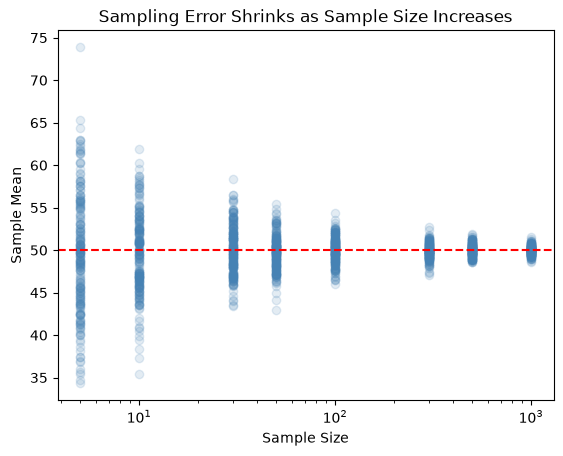

In [19]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)
population = np.random.normal(50, 15, 100000)
true_mean = np.mean(population)
sample_sizes = [5, 10, 30, 50, 100, 300, 500, 1000]
for n in sample_sizes:
    sample_means = [np.mean(np.random.choice(population, n, replace=False)) for _ in range(200)]
    plt.scatter([n] * 200, sample_means, alpha=0.15, color='steelblue')
plt.axhline(true_mean, color='red', linestyle='--')
plt.xscale('log')
plt.xlabel('Sample Size')
plt.ylabel('Sample Mean')
plt.title('Sampling Error Shrinks as Sample Size Increases')
plt.show()

**Interpretation**: The spread of sample means around the true mean shrinks as sample size increases.

## 07. Sample Size

**Definition**: The number of observations included in a sample, chosen to balance accuracy against cost and time.

**Formula**: n = (Z × σ / E)²

**Where it is used**: Survey design, clinical trials, A/B testing.

**Real-World Example**: A drug trial needing 385 patients for 95% confidence and 5% margin of error.

**AI/ML Example**: Calculating minimum visitors needed per variant before running an A/B test.

In [16]:
import numpy as np
Z = 1.96
sigma = 15
E = 2
n_required = (Z * sigma / E) ** 2
print(int(np.ceil(n_required)))
for n in [10, 30, 100, 385, 1000]:
    print(n, Z * sigma / np.sqrt(n))

217
10 9.297096320895035
30 5.367681063550628
100 2.94
385 1.498362742826619
1000 0.9297096320895035


**Interpretation**: As sample size increases, the margin of error shrinks but with diminishing returns.

## Overall Advantages and Limitations of Sampling

### Advantages
1. Cost and time efficient compared to studying an entire population.
2. Makes analysis feasible when the population is too large or infinite.
3. Enables inferential statistics through confidence intervals and hypothesis tests.
4. Avoids destructive testing of an entire population.
5. Different techniques can be tailored to population structure and resources.

### Limitations
1. Sampling error is inevitable even with perfect execution.
2. Sampling bias can misrepresent the population and does not improve with more data.
3. Stratified and cluster sampling require prior knowledge of population structure.
4. Small sample sizes reduce statistical power.
5. Non-response can reintroduce bias even in well-designed samples.

## Interview Questions & Answers

**1. What is the difference between a population and a sample, and why do we sample instead of studying the entire population?**
A population is the entire group we want to study, while a sample is a smaller subset drawn from it; we sample because studying the whole population is often too costly, time-consuming, or physically impossible.

**2. Explain the difference between sampling error and sampling bias. Can increasing sample size fix both?**
Sampling error is the random, unavoidable difference between a sample statistic and the true population value, and it shrinks as sample size increases, whereas sampling bias is a systematic distortion caused by a flawed selection method that does not improve no matter how large the sample gets.

**3. When would you prefer stratified sampling over simple random sampling?**
Stratified sampling is preferred when the population has meaningful subgroups (like age, gender, or class labels) and we need each subgroup proportionally represented, such as ensuring a minority class isn't underrepresented in a train-test split.

**4. How does cluster sampling differ from stratified sampling in terms of cost vs precision?**
Cluster sampling selects entire naturally occurring groups (like schools or cities) and samples all members within them, making it cheaper and more practical for spread-out populations, but it usually gives less precise estimates than stratified sampling, which samples from every subgroup individually.

**5. How do you determine the minimum sample size needed for a survey or an A/B test?**
The minimum sample size is calculated using a formula based on the desired confidence level (Z-score), the population's variability (standard deviation), and the acceptable margin of error, using n = (Z × σ / E)².

**6. What is sampling with vs without replacement, and how does it affect probability calculations?**
Sampling with replacement means an individual can be selected more than once because it's returned to the population after selection, keeping selection probabilities constant, while sampling without replacement removes each selected individual permanently, slightly changing the probabilities for remaining draws.

**7. How does the Central Limit Theorem relate to sampling and the sample mean?**
The Central Limit Theorem states that the distribution of sample means approaches a normal distribution as sample size increases, regardless of the population's original distribution, which is why larger samples give more reliable and normally-distributed estimates of the population mean.

**8. Why is stratified sampling important when splitting an imbalanced dataset into train/test sets?**
Stratified sampling ensures that both the train and test sets maintain the same class proportions as the original dataset, preventing situations where a minority class (like fraud cases) is missing or underrepresented in one of the splits, which would lead to unreliable model evaluation.

## Self-Reflection

Working through this notebook deepened my understanding of sampling as a foundational pillar of statistics and data science, since nearly every dataset used in AI/ML is a sample rather than a full population. The key distinction I take away is between sampling error, which is random and shrinks with larger samples, and sampling bias, which is systematic and does not improve with more data. This connects directly to AI fairness issues, since a biased training sample produces a biased model regardless of data volume. I also better understand how the choice of sampling technique depends on population structure and the trade-off between statistical precision and practical cost.